## 3-stimulus / 2-context swap task — RNN actor-critic

Parameterised task: set `n_swap_lohi`, `n_fixed_mid`, `n_swap_hilow`, `n_anchor_low`, `n_anchor_high` in the **Task** cell to control the number of stimuli per category.

Figures live in `13_05_26_vis_inference.ipynb`; this notebook trains, runs inference, and saves `vis_data.pkl`.

In [110]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [111]:
from collections import defaultdict
from datetime import datetime
from pathlib import Path
import pickle

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Categorical

from cxval.tasks import StimulusSequence, StateSequence
from cxval.envs import TaskEnv
from cxval.models import RNN, ActorCritic
from cxval.agents import Agent
from cxval.vis import STYLE

plt.style.use(STYLE)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


## 1. Task

In [112]:
def build_value_matrix(
    n_swap_lohi   = 1,   # [0.0, 1.0]  low in c0, high in c1
    n_fixed_mid   = 1,   # [0.5, 0.5]
    n_swap_hilow  = 1,   # [1.0, 0.0]  high in c0, low in c1
    n_anchor_low  = 0,   # [0.0, 0.0]
    n_anchor_high = 0,   # [1.0, 1.0]
):
    group_specs = [
        ("swap (low\u2192high)", "swap\n(lo\u2192hi)",  [0.0, 1.0], n_swap_lohi),
        ("mid",                   "mid",                   [0.5, 0.5], n_fixed_mid),
        ("swap (high\u2192low)", "swap\n(hi\u2192lo)", [1.0, 0.0], n_swap_hilow),
        ("anchor (low)",          "anchor\n(low)",        [0.0, 0.0], n_anchor_low),
        ("anchor (high)",         "anchor\n(high)",       [1.0, 1.0], n_anchor_high),
    ]
    rows, si = [], 0
    stim_group_info = []
    for gname, gshort, gvals, n in group_specs:
        if n == 0:
            continue
        stim_group_info.append({
            "name":    gname,
            "short":   gshort,
            "indices": list(range(si, si + n)),
        })
        rows.extend([gvals] * n)
        si += n
    return np.array(rows, dtype=np.float32), [f"s{i}" for i in range(si)], stim_group_info


# ── task configuration ────────────────────────────────────────────────
# 3-stimulus / 2-context swap task
value_matrix, stimuli, stim_group_info = build_value_matrix(
    n_swap_lohi=1,    # s0: [0.0, 1.0]
    n_fixed_mid=1,    # s1: [0.5, 0.5]
    n_swap_hilow=1,   # s2: [1.0, 0.0]
)
n_contexts = 2
n_stimuli  = len(stimuli)
contexts   = ["c0", "c1"]

if n_contexts > 1:
    id_val_r = np.corrcoef(value_matrix[:, 0], value_matrix[:, 1])[0, 1]
    print(f"Identity\u2013value correlation across contexts: r = {id_val_r:.3f}")
print(f"n_stimuli = {n_stimuli}")
for g in stim_group_info:
    print(f"  {g['name']}: {[stimuli[i] for i in g['indices']]}")

# ── task timing ──────────────────────────────────────────────────────────
trials_per_phase   = 300
phases_per_context = 1
context_reps       = 30
stim_timesteps     = 5
reward_timesteps   = 3
iti_timesteps      = (3, 8)
seed               = 42

stim_seq = StimulusSequence(
    value_matrix=value_matrix,
    trials_per_phase=trials_per_phase,
    phases_per_context=phases_per_context,
    context_order="sequential",
    context_reps=context_reps,
)
stim_seq.generate(seed=seed)

state_seq = StateSequence(
    stimulus_sequence=stim_seq,
    value_matrix=value_matrix,
    stim_timesteps=stim_timesteps,
    reward_timesteps=reward_timesteps,
    iti_timesteps=iti_timesteps,
)
states, rewards, reward_availability = state_seq.generate(seed=seed)

n_trials = len(stim_seq.trial_contexts)
obs_dim  = states.shape[1] + 2

print(f"\nValue matrix:\n{value_matrix}")
print(f"Trials: {n_trials}  |  Sequence: {len(states)} timesteps  |  Obs dim: {obs_dim}")

Identity–value correlation across contexts: r = -1.000
n_stimuli = 3
  swap (low→high): ['s0']
  mid: ['s1']
  swap (high→low): ['s2']

Value matrix:
[[0.  1. ]
 [0.5 0.5]
 [1.  0. ]]
Trials: 18000  |  Sequence: 243202 timesteps  |  Obs dim: 8


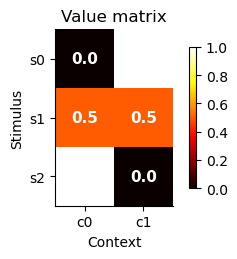

In [113]:
# value matrix heatmap
fig, ax = plt.subplots(figsize=(2.5 + 0.5 * n_contexts, 1.5 + 0.4 * n_stimuli))
im = ax.imshow(value_matrix, cmap="hot", vmin=0, vmax=1, aspect="equal")
for i in range(n_stimuli):
    for j in range(n_contexts):
        v = value_matrix[i, j]
        ax.text(j, i, f"{v:.1f}", ha="center", va="center",
                color="white", fontsize=11, fontweight="bold")
ax.set_yticks(range(n_stimuli)); ax.set_yticklabels(stimuli)
ax.set_xticks(range(n_contexts)); ax.set_xticklabels(contexts)
ax.set_ylabel("Stimulus"); ax.set_xlabel("Context")
ax.set_title("Value matrix")
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

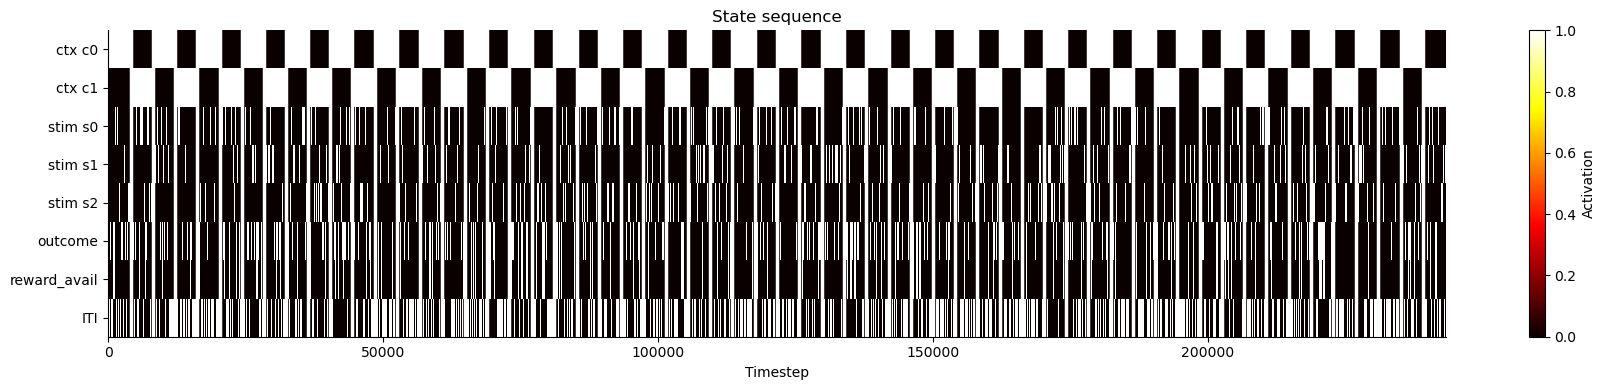

In [114]:
# state sequence structure
trial_starts     = np.array([t["trial_start"] for t in state_seq.trial_structure])
context_at_trial = np.array([t["context"]     for t in state_seq.trial_structure])
ctx_change_idx   = np.where(np.diff(context_at_trial) != 0)[0] + 1
context_bnd_ts   = trial_starts[ctx_change_idx]

iti_indicator = (
    (states[:, n_contexts : n_contexts + n_stimuli].sum(axis=1) == 0) &
    (states[:, -1] == 0)
).astype(float)

vis_states = np.vstack([
    states.T,
    reward_availability[None, :],
    iti_indicator[None, :],
])
ylabels = (
    [f"ctx {c}" for c in contexts]
    + [f"stim {s}" for s in stimuli]
    + ["outcome", "reward_avail", "ITI"]
)

ctx_colors = [plt.cm.Set2(v) for v in np.linspace(0, 0.75, max(n_contexts, 1))]

fig, ax = plt.subplots(figsize=(18, 4))
im = ax.imshow(vis_states, aspect="auto", cmap="hot", vmin=0, vmax=1, interpolation="nearest")
for t in context_bnd_ts:
    ax.axvline(t - 0.5, color="white", linewidth=2.5)
ax.set_yticks(range(len(ylabels)))
ax.set_yticklabels(ylabels)
ax.set_xlabel("Timestep")
ax.set_title("State sequence")
plt.colorbar(im, ax=ax, label="Activation")
plt.tight_layout()
plt.show()

## 2. Model

In [115]:
lick_cost    = 0.0    # matches mid sweep combo 12
policy_clip  = 0.1    # fixed from training hyperparams sweep

env = TaskEnv(
    states=states,
    reward_availability=reward_availability,
    reward_lick=1.0,
    reward_no_lick=0.0,
    reward_lick_miss=-1.0,
    lick_cost=lick_cost,
)

hidden_size    = 64
num_actions    = 2
recurrent_gain = 0.9

backbone     = RNN(input_size=obs_dim, hidden_size=hidden_size, output_size=1,
                   recurrent_gain=recurrent_gain)
actor_critic = ActorCritic(backbone=backbone, num_actions=num_actions,
                           policy_clip=policy_clip).to(device)
agent        = Agent(actor_critic, device=device)

n_params = sum(p.numel() for p in actor_critic.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")
print(f"policy_clip={policy_clip}  lick_cost={lick_cost}")

Trainable parameters: 4,996
policy_clip=0.1  lick_cost=0.0


## 3. Train

In [116]:
def compute_returns(rewards, bootstrap_value, gamma):
    returns, R = [], float(bootstrap_value)
    for r in reversed(rewards):
        R = r + gamma * R
        returns.append(R)
    returns.reverse()
    return returns

In [117]:
n_episodes   = 1
bptt_len     = 10
update_every = 10
gamma        = 0
lr           = 9e-4
value_coef   = 0.5
entropy_coef = 0.1    # matches mid sweep combo 12
grad_clip    = 1.0

optimizer = torch.optim.Adam(actor_critic.parameters(), lr=lr)

actor_losses    = []
critic_losses   = []
all_trial_data  = []
hidden_np_train = None

for episode in range(n_episodes):
    obs, _ = env.reset()
    hidden = None
    actor_critic.train()

    log_probs_buf, values_buf, rewards_buf, entropies_buf = [], [], [], []
    action_list, reward_list, info_list = [], [], []
    value_ts = []

    is_last = (episode == n_episodes - 1)
    if is_last:
        hidden_ts_list = []

    optimizer.zero_grad()
    t_in_window = 0
    n_opt_steps = 0
    done = False
    t    = 0

    while not done:
        obs_t  = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
        logits, value, hidden = actor_critic.step(obs_t, hidden)
        dist   = actor_critic.make_dist(logits)
        action = dist.sample()

        log_probs_buf.append(dist.log_prob(action))
        values_buf.append(value)
        entropies_buf.append(dist.entropy())
        value_ts.append(value.detach().item())

        if is_last:
            hidden_ts_list.append(hidden.detach().squeeze(0))

        action_list.append(action.item())
        obs, reward, done, _, info = env.step(action.item())
        rewards_buf.append(reward)
        reward_list.append(reward)
        info_list.append(info)
        t           += 1
        t_in_window += 1

        if t % update_every == 0 or done:
            if done:
                bootstrap_v = 0.0
            else:
                with torch.no_grad():
                    obs_next = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)
                    _, bv, _ = actor_critic.step(obs_next, hidden)
                    bootstrap_v = bv.item()

            returns      = compute_returns(rewards_buf, bootstrap_v, gamma)
            log_probs_t  = torch.stack(log_probs_buf).squeeze(-1)
            values_t     = torch.stack(values_buf).squeeze(-1)
            returns_t    = torch.tensor(returns, dtype=torch.float32, device=device)
            entropy_mean = torch.stack(entropies_buf).mean()

            advantages = returns_t - values_t.detach()
            adv_std = advantages.std()
            if adv_std > 1e-4:
                advantages = (advantages - advantages.mean()) / (adv_std + 1e-8)
            else:
                advantages = advantages - advantages.mean()

            actor_loss  = -(log_probs_t * advantages).mean()
            critic_loss = F.mse_loss(values_t, returns_t)
            loss        = actor_loss + value_coef * critic_loss - entropy_coef * entropy_mean

            is_last_in_window = (t_in_window >= bptt_len) or done
            loss.backward(retain_graph=not is_last_in_window)

            actor_losses.append(actor_loss.item())
            critic_losses.append(critic_loss.item())

            log_probs_buf, values_buf, rewards_buf, entropies_buf = [], [], [], []

            if is_last_in_window:
                nn.utils.clip_grad_norm_(actor_critic.parameters(), grad_clip)
                optimizer.step()
                optimizer.zero_grad()
                n_opt_steps += 1
                hidden = hidden.detach()
                t_in_window = 0

    if is_last:
        hidden_np_train = np.array(torch.stack(hidden_ts_list).tolist(), dtype=np.float32)

    for ti, trial in enumerate(state_seq.trial_structure):
        rs, re = trial["reward_window"]
        all_trial_data.append({
            "global_trial":     episode * n_trials + ti,
            "context":          trial["context"],
            "stimulus":         trial["stimulus"],
            "reward_available": trial["reward_available"],
            "licked":           int(action_list[rs] == TaskEnv.LICK),
            "value_estimate":   float(np.mean(value_ts[rs:re])),
            "lick_count":       sum(1 for a in action_list[rs:re] if a == TaskEnv.LICK),
        })

    n_loss_evals = len(actor_losses)
    print(f"ep {episode+1}/{n_episodes} | "
          f"bptt_len={bptt_len} | update_every={update_every} | "
          f"loss evals: {n_loss_evals} | optimizer steps: {n_opt_steps}")

print(f"Training hidden states shape: {hidden_np_train.shape}")

ep 1/1 | bptt_len=10 | update_every=10 | loss evals: 24321 | optimizer steps: 24321
Training hidden states shape: (243202, 64)


## 4. Loss

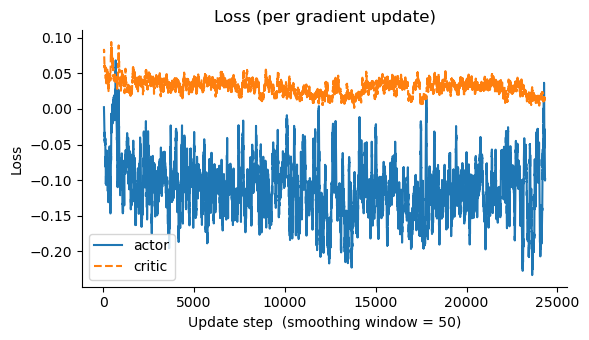

In [118]:
def smooth(x, w):
    x = np.array(x, dtype=float)
    if len(x) < w:
        return x, np.arange(len(x))
    return np.convolve(x, np.ones(w) / w, mode="valid"), np.arange(w - 1, len(x))

upd_w = max(1, min(50, len(actor_losses) // 10))

fig, ax = plt.subplots(figsize=(6, 3.5))
s_a, x_a = smooth(actor_losses,  upd_w)
s_c, x_c = smooth(critic_losses, upd_w)
ax.plot(x_a, s_a, label="actor")
ax.plot(x_c, s_c, label="critic", linestyle="--")
ax.set_title("Loss (per gradient update)")
ax.set_xlabel(f"Update step  (smoothing window = {upd_w})")
ax.set_ylabel("Loss")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Per-stimulus traces

In [119]:
# ── inference run: one block per context, plasticity off ──────────────────────
infer_stim_seq = StimulusSequence(
    value_matrix=value_matrix,
    trials_per_phase=trials_per_phase,
    phases_per_context=1,
    context_order="sequential",
    context_reps=1,
)
infer_stim_seq.generate(seed=seed + 1)

infer_state_seq = StateSequence(
    stimulus_sequence=infer_stim_seq,
    value_matrix=value_matrix,
    stim_timesteps=stim_timesteps,
    reward_timesteps=reward_timesteps,
    iti_timesteps=iti_timesteps,
)
infer_states, _, infer_reward_avail = infer_state_seq.generate(seed=seed + 1)

infer_env = TaskEnv(
    states=infer_states,
    reward_availability=infer_reward_avail,
    reward_lick=env.reward_lick,
    reward_no_lick=env.reward_no_lick,
    reward_lick_miss=env.reward_lick_miss,
    lick_cost=lick_cost,
)

actor_critic.eval()
agent.reset()
obs, _ = infer_env.reset()
infer_action_seq, infer_value_ts, infer_hidden_list = [], [], []
done = False
while not done:
    action, _, value = agent.act(obs)
    infer_action_seq.append(action)
    infer_value_ts.append(value.item())
    infer_hidden_list.append(agent.hidden.detach().squeeze(0))
    obs, _, done, _, _ = infer_env.step(action)

infer_hidden_np = np.array(torch.stack(infer_hidden_list).tolist(), dtype=np.float32)

infer_n_trials = len(infer_state_seq.trial_structure)
infer_trial_data = []
for ti, trial in enumerate(infer_state_seq.trial_structure):
    rs, re = trial["reward_window"]
    infer_trial_data.append({
        "global_trial":     n_trials + ti,
        "context":          trial["context"],
        "stimulus":         trial["stimulus"],
        "reward_available": trial["reward_available"],
        "licked":           int(infer_action_seq[rs] == TaskEnv.LICK),
        "value_estimate":   float(np.mean(infer_value_ts[rs:re])),
        "lick_count":       sum(1 for a in infer_action_seq[rs:re] if a == TaskEnv.LICK),
    })

infer_td = np.array([
    (d["global_trial"], d["context"], d["stimulus"],
     d["reward_available"], d["licked"], d["value_estimate"], d["lick_count"])
    for d in infer_trial_data
])
print(f"Inference: {infer_n_trials} trials, hidden states: {infer_hidden_np.shape}")

Inference: 600 trials, hidden states: (8111, 64)


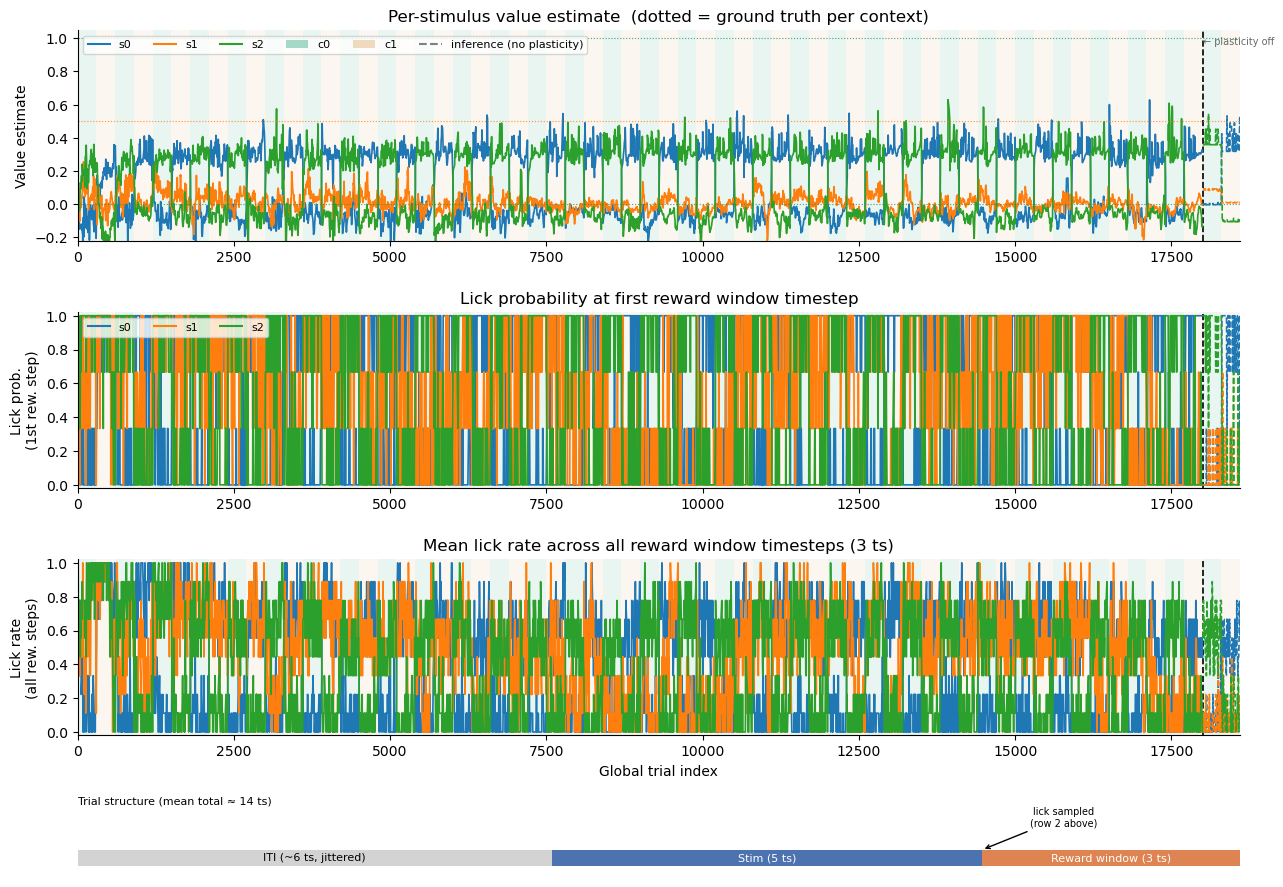

In [120]:
td = np.array([
    (d["global_trial"], d["context"], d["stimulus"],
     d["reward_available"], d["licked"], d["value_estimate"], d["lick_count"])
    for d in all_trial_data
])

total_n_trials = n_trials + infer_n_trials

_ctx_arr       = np.array([t["context"] for t in state_seq.trial_structure])
_infer_ctx_arr = np.array([d["context"] for d in infer_trial_data])
_combined_ctx  = np.concatenate([_ctx_arr, _infer_ctx_arr])
_chg_idx         = np.where(np.diff(_combined_ctx) != 0)[0] + 1
ctx_block_starts = np.concatenate([[0], _chg_idx])
ctx_block_ends   = np.concatenate([_chg_idx, [total_n_trials]])
ctx_block_ctxs   = _combined_ctx[ctx_block_starts]

ctx_colors  = [plt.cm.Set2(v) for v in np.linspace(0, 0.75, max(n_contexts, 1))]
stim_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
smooth_w = max(1, min(3, n_trials // 10))

fig, axes = plt.subplots(4, 1, figsize=(15, 11),
                         gridspec_kw={"height_ratios": [3, 2.5, 2.5, 1], "hspace": 0.45})

for bs, be, ctx in zip(ctx_block_starts, ctx_block_ends, ctx_block_ctxs):
    for ax in axes[:3]:
        ax.axvspan(bs - 0.5, be - 0.5, alpha=0.15, color=ctx_colors[ctx], zorder=0, linewidth=0)

for ax in axes[:3]:
    ax.axvline(n_trials - 0.5, color="black", linewidth=1.2, linestyle="--", zorder=2)

all_val_smoothed = []
for si in range(n_stimuli):
    c = stim_colors[si % len(stim_colors)]
    for data_td, ls in [(td, "-"), (infer_td, "--")]:
        mask        = data_td[:, 2] == si
        gt          = data_td[mask, 0].astype(int)
        val         = data_td[mask, 5]
        lick        = data_td[mask, 4]
        lick_rate_w = data_td[mask, 6] / reward_timesteps
        if smooth_w > 1 and len(val) >= smooth_w:
            sv  = np.convolve(val,         np.ones(smooth_w) / smooth_w, mode="valid")
            sl  = np.convolve(lick,        np.ones(smooth_w) / smooth_w, mode="valid")
            slr = np.convolve(lick_rate_w, np.ones(smooth_w) / smooth_w, mode="valid")
            xax = gt[smooth_w - 1:]
        else:
            sv, sl, slr, xax = val, lick, lick_rate_w, gt
        all_val_smoothed.append(sv)
        axes[0].plot(xax, sv,  color=c, linewidth=1.2, linestyle=ls)
        axes[1].plot(xax, sl,  color=c, linewidth=1.2, linestyle=ls)
        axes[2].plot(xax, slr, color=c, linewidth=1.2, linestyle=ls)

all_val_smoothed = np.concatenate(all_val_smoothed)
v_lo = min(0.0, np.percentile(all_val_smoothed, 1))
v_hi = max(1.0, np.percentile(all_val_smoothed, 99))
axes[0].set_ylim(v_lo - 0.05, v_hi + 0.05)

for si in range(n_stimuli):
    c = stim_colors[si % len(stim_colors)]
    for ci in range(n_contexts):
        axes[0].axhline(value_matrix[si, ci], color=c, linestyle=":", linewidth=0.8, alpha=0.5)

axes[0].text(n_trials + 0.5, 0.97, "← plasticity off",
             transform=axes[0].get_xaxis_transform(),
             fontsize=7, ha="left", va="top", color="dimgray")

stim_handles = [Line2D([0],[0], color=stim_colors[si % len(stim_colors)], label=stimuli[si])
                for si in range(n_stimuli)]
ctx_handles  = [Patch(facecolor=ctx_colors[c], alpha=0.6, label=contexts[c])
                for c in range(n_contexts)]
infer_handle = Line2D([0],[0], color="gray", linestyle="--", label="inference (no plasticity)")

axes[0].legend(handles=stim_handles + ctx_handles + [infer_handle],
               ncol=n_stimuli + n_contexts + 1, fontsize=8, loc="upper left")
axes[0].set_ylabel("Value estimate")
axes[0].set_title("Per-stimulus value estimate  (dotted = ground truth per context)")

axes[1].legend(handles=stim_handles, ncol=n_stimuli, fontsize=8, loc="upper left")
axes[1].set_ylabel("Lick prob.\n(1st rew. step)")
axes[1].set_ylim(-0.02, 1.02)
axes[1].set_title("Lick probability at first reward window timestep")

axes[2].set_ylabel("Lick rate\n(all rew. steps)")
axes[2].set_ylim(-0.02, 1.02)
axes[2].set_xlabel("Global trial index")
axes[2].set_title(f"Mean lick rate across all reward window timesteps ({reward_timesteps} ts)")

for ax in axes[:3]:
    ax.set_xlim(0, total_n_trials - 1)

# ── trial structure schematic ──────────────────────────────────────────────────
ax = axes[3]
avg_iti   = state_seq.iti_durations.mean()
total_ts  = avg_iti + stim_timesteps + reward_timesteps
iti_frac  = avg_iti / total_ts
stim_frac = stim_timesteps / total_ts

for xstart, xend, color, label in [
    (0,                    iti_frac,             "lightgray", f"ITI (~{avg_iti:.0f} ts, jittered)"),
    (iti_frac,             iti_frac + stim_frac, "#4C72B0",   f"Stim ({stim_timesteps} ts)"),
    (iti_frac + stim_frac, 1.0,                  "#DD8452",   f"Reward window ({reward_timesteps} ts)"),
]:
    ax.barh(0, xend - xstart, left=xstart, height=0.5, color=color)
    ax.text((xstart + xend) / 2, 0, label, ha="center", va="center", fontsize=8,
            color="black" if color == "lightgray" else "white")

lick_x = iti_frac + stim_frac
ax.annotate("lick sampled\n(row 2 above)", xy=(lick_x, 0.25), xytext=(lick_x + 0.07, 1.0),
            arrowprops=dict(arrowstyle="->", color="black", lw=1.0), fontsize=7, ha="center")

ax.set_xlim(0, 1); ax.set_ylim(-0.6, 1.6); ax.axis("off")
ax.set_title(f"Trial structure (mean total ≈ {total_ts:.0f} ts)", fontsize=8, loc="left", pad=2)
plt.show()

## 6. Save

In [121]:
run_id = (
    f"RNN_{n_stimuli}s{n_contexts}c"
    f"_h{hidden_size}_g{recurrent_gain}"
    f"_ep{n_episodes}_bptt{bptt_len}_upd{update_every}"
    f"_seed{seed}"
    f"_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
)

run_dir = Path("../results") / run_id
run_dir.mkdir(parents=True, exist_ok=True)

# per-trial hidden state slices for decoding
_infer_context_arr          = np.array([t["context"]          for t in infer_state_seq.trial_structure])
_infer_stimulus_arr         = np.array([t["stimulus"]         for t in infer_state_seq.trial_structure])
_infer_reward_available_arr = np.array([t["reward_available"] for t in infer_state_seq.trial_structure])
_infer_stim_hidden   = np.stack([infer_hidden_np[t["stim_window"][0]   : t["stim_window"][1]]
                                  for t in infer_state_seq.trial_structure])
_infer_reward_hidden = np.stack([infer_hidden_np[t["reward_window"][0] : t["reward_window"][1]]
                                  for t in infer_state_seq.trial_structure])

# assemble infer_activations dict for vis notebook decoding
infer_activations = {
    "hidden_states":    infer_hidden_np,
    "stim_hidden":      _infer_stim_hidden,
    "reward_hidden":    _infer_reward_hidden,
    "context":          _infer_context_arr,
    "stimulus":         _infer_stimulus_arr,
    "reward_available": _infer_reward_available_arr,
    "trial_structure":  infer_state_seq.trial_structure,
}

# derive stim_groups from stim_group_info so decoding works for any task config
_swap_idx   = [i for g in stim_group_info if "swap"   in g["name"] for i in g["indices"]]
_anchor_idx = [i for g in stim_group_info if "anchor" in g["name"] for i in g["indices"]]
stim_groups  = {"all": None}
group_colors = {"all": "black"}
if _swap_idx:
    stim_groups["swap"]  = _swap_idx
    group_colors["swap"] = "tomato"
if _anchor_idx:
    stim_groups["anchor"]  = _anchor_idx
    group_colors["anchor"] = "steelblue"

pooling = "average"
n_folds = 5

vis_data = {
    "value_matrix":               value_matrix,
    "n_stimuli":                  n_stimuli,
    "n_contexts":                 n_contexts,
    "stimuli":                    stimuli,
    "contexts":                   contexts,
    "stim_group_info":            stim_group_info,
    "stim_timesteps":             stim_timesteps,
    "reward_timesteps":           reward_timesteps,
    "reward_lick":                env.reward_lick,
    "reward_lick_miss":           env.reward_lick_miss,
    "reward_no_lick":             env.reward_no_lick,
    "lick_cost":                  lick_cost,
    "n_trials":                   n_trials,
    "trials_per_phase":           trials_per_phase,
    "context_reps":               context_reps,
    "all_trial_data":             all_trial_data,
    "infer_trial_data":           infer_trial_data,
    "infer_action_seq":           infer_action_seq,
    "infer_trial_structure":      infer_state_seq.trial_structure,
    "infer_stim_hidden":          _infer_stim_hidden,
    "infer_reward_hidden":        _infer_reward_hidden,
    "infer_context_arr":          _infer_context_arr,
    "infer_stimulus_arr":         _infer_stimulus_arr,
    "infer_reward_available_arr": _infer_reward_available_arr,
    # decoding data — loaded by 13_05_26_vis_inference.ipynb
    "infer_activations":          infer_activations,
    "stim_groups":                stim_groups,
    "group_colors":               group_colors,
    "pooling":                    pooling,
    "n_folds":                    n_folds,
}

with open(run_dir / "vis_data.pkl", "wb") as f:
    pickle.dump(vis_data, f, protocol=pickle.HIGHEST_PROTOCOL)

torch.save(actor_critic.state_dict(), run_dir / "model.pt")

# ── value matrix heatmap ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(2.5 + 0.5 * n_contexts, 1.5 + 0.4 * n_stimuli))
im = ax.imshow(value_matrix, cmap="hot", vmin=0, vmax=1, aspect="equal")
for i in range(n_stimuli):
    for j in range(n_contexts):
        v = value_matrix[i, j]
        ax.text(j, i, f"{v:.1f}", ha="center", va="center",
                color="white", fontsize=11, fontweight="bold")
ax.set_yticks(range(n_stimuli)); ax.set_yticklabels(stimuli)
ax.set_xticks(range(n_contexts)); ax.set_xticklabels(contexts)
ax.set_ylabel("Stimulus"); ax.set_xlabel("Context")
ax.set_title("Value matrix")
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
fig.savefig(run_dir / "value_matrix.png", dpi=150, bbox_inches="tight")
plt.close(fig)

# ── state sequence ────────────────────────────────────────────────────────
_trial_starts     = np.array([t["trial_start"] for t in state_seq.trial_structure])
_context_at_trial = np.array([t["context"]     for t in state_seq.trial_structure])
_ctx_change_idx   = np.where(np.diff(_context_at_trial) != 0)[0] + 1
_context_bnd_ts   = _trial_starts[_ctx_change_idx]

_iti_indicator = (
    (states[:, n_contexts : n_contexts + n_stimuli].sum(axis=1) == 0) &
    (states[:, -1] == 0)
).astype(float)

_vis_states = np.vstack([
    states.T,
    reward_availability[None, :],
    _iti_indicator[None, :],
])
_ylabels = (
    [f"ctx {c}" for c in contexts]
    + [f"stim {s}" for s in stimuli]
    + ["outcome", "reward_avail", "ITI"]
)

fig, ax = plt.subplots(figsize=(18, 4))
im = ax.imshow(_vis_states, aspect="auto", cmap="hot", vmin=0, vmax=1, interpolation="nearest")
for t in _context_bnd_ts:
    ax.axvline(t - 0.5, color="white", linewidth=2.5)
ax.set_yticks(range(len(_ylabels)))
ax.set_yticklabels(_ylabels)
ax.set_xlabel("Timestep")
ax.set_title("State sequence")
plt.colorbar(im, ax=ax, label="Activation")
plt.tight_layout()
fig.savefig(run_dir / "state_sequence.png", dpi=150, bbox_inches="tight")
plt.close(fig)

print(f"run_id : {run_id}")
print(f"Saved  → {run_dir}")

run_id : RNN_3s2c_h64_g0.9_ep1_bptt10_upd10_seed42_20260514_125857
Saved  → ../results/RNN_3s2c_h64_g0.9_ep1_bptt10_upd10_seed42_20260514_125857
